# 08i — Discrete Bayesian selection with BoTorch

This notebook uses the complete 24-design ProteinMPNN pool and authentic CamSol results. A `SingleTaskGP` is trained only on the five candidates with real FoldX and Rosetta observations. `LogExpectedImprovement` is evaluated on the remaining discrete pool to select the next candidate for expensive structural validation.

The model is a **small-sample pilot**. It does not predict binding affinity, does not impute MD/endpoint results, and does not generate a novel peptide.

In [1]:
# If the imports below fail, run this once in the active kernel, restart, then Run All:
# %pip install botorch gpytorch

from pathlib import Path
import json, os, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root_candidates=[Path(os.environ.get("PEARL_ROOT","")),Path.cwd(),Path('/Users/robertobruzzese/Desktop/venv')]
ROOT=next((p for p in root_candidates if (p/'outputs/pipeline_4_ai_08b_proteinmpnn').exists()),None)
if ROOT is None: raise FileNotFoundError("PEARL root not found; set PEARL_ROOT to the directory containing outputs/")
OUTPUT_ROOT = ROOT/"outputs/pipeline_4_ai_08i_bayesian_optimisation"
TABLE_DIR, FIGURE_DIR, PROVENANCE_DIR = (OUTPUT_ROOT/x for x in ("tables","figures","provenance"))
for d in (TABLE_DIR, FIGURE_DIR, PROVENANCE_DIR): d.mkdir(parents=True, exist_ok=True)

P08B = ROOT/"outputs/pipeline_4_ai_08b_proteinmpnn/production/tables/08b_ProteinMPNN_unique_designs.csv"
P08C = ROOT/"outputs/pipeline_4_ai_08c_integrated_candidate_selection/tables/08c_ESM2_all_sequence_scores.csv"
P08D = ROOT/"outputs/pipeline_4_ai_08d_structural_validation/tables/08d_integrated_structural_ranking.csv"
P08H = ROOT/"outputs/pipeline_4_ai_08h_solubility_developability/tables/08h_solubility_developability_summary.csv"
for p in (P08B,P08C,P08D,P08H):
    if not p.exists(): raise FileNotFoundError(p)
print("Inputs found")

Inputs found


## Harmonise identities and evidence

The canonical pool identifier is `MPNN_POOL_###` from the 08b production rank. Shortlist aliases such as `MPNN_NEW_01` are retained as annotations. Identity joins use the peptide sequence; uniqueness is checked before every merge.

In [2]:
b=pd.read_csv(P08B); c=pd.read_csv(P08C); d=pd.read_csv(P08D); h=pd.read_csv(P08H)
for frame,col in ((b,"peptide_sequence"),(c,"sequence"),(d,"peptide_sequence"),(h,"sequence")):
    if frame[col].duplicated().any(): raise ValueError(f"Duplicate sequence in {col}")

pool=b.rename(columns={"peptide_sequence":"sequence"}).copy()
pool["candidate_id"] = pool["ProteinMPNN_rank"].map(lambda x:f"MPNN_POOL_{int(x):03d}")
esm=c[c["source"].astype(str).str.startswith("ProteinMPNN")][["sequence","ESM2_PLL_mean","ESM2_pseudo_perplexity"]]
cam=h[["candidate_id","sequence","sequence_sha256","camsol_overall_score","camsol_result_validated"]]
pool=pool.merge(esm,on="sequence",how="left",validate="one_to_one")
pool=pool.merge(cam,on=["candidate_id","sequence"],how="left",validate="one_to_one")
aliases=d[["candidate_id","peptide_sequence","foldx_interaction_energy_kcal_mol","best_I_sc","structural_rank"]].rename(columns={"candidate_id":"shortlist_alias","peptide_sequence":"sequence"})
pool=pool.merge(aliases,on="sequence",how="left",validate="one_to_one")

required=["best_ProteinMPNN_score","ESM2_PLL_mean","camsol_overall_score"]
if pool[required].isna().any().any(): raise ValueError("Missing common feature in the 24-design pool")
if len(pool)!=24 or not pool["camsol_result_validated"].all(): raise ValueError("Expected 24 designs with validated CamSol")
display(pool.head()); print("Pool:",len(pool),"Structural observations:",pool.shortlist_alias.notna().sum())

,ProteinMPNN_rank,sequence,sample_count,best_ProteinMPNN_score,mean_ProteinMPNN_score,best_global_score,min_hamming_vs_F0010,matches_F0010,matches_CF06,matches_CF02,candidate_id,ESM2_PLL_mean,ESM2_pseudo_perplexity,sequence_sha256,camsol_overall_score,camsol_result_validated,shortlist_alias,foldx_interaction_energy_kcal_mol,best_I_sc,structural_rank
0,1,TGPRNQYRDLP,34,1.2473,1.300118,1.5296,4,False,False,False,MPNN_POOL_001,-3.172003,23.855210,2aabd4dfdefe34755b3409eb7c510495268239b597adac...,2.185477,True,MPNN_NEW_01,-11.7407,-54.169,2.0
1,2,TGPRNQYRDLN,25,1.2479,1.305864,1.5373,4,False,False,False,MPNN_POOL_002,-3.200399,24.542312,229d049245c811316c9835bfca44a4b04ba683611f4e3a...,2.184338,True,NaN,NaN,NaN,NaN
2,3,TGPRNQYRDLG,14,1.2572,1.321343,1.5397,4,False,False,False,MPNN_POOL_003,-3.168259,23.766081,3d83a6ce9408abaa93ed37f0b7db0085dc5054561c3855...,2.172541,True,NaN,NaN,NaN,NaN
3,4,VGPRNQYRDLP,3,1.2978,1.314500,1.5479,4,False,False,False,MPNN_POOL_004,-3.139989,23.103615,0ca0ac771554aef1ec27423c7d2361a3295dab47310741...,2.052727,True,NaN,NaN,NaN,NaN
4,5,IGPRNQYRDLN,2,1.3458,1.374800,1.5526,3,False,False,False,MPNN_POOL_005,-3.193722,24.379001,3ef96bfc9cdc503e6fcbb37555a2168c655697177b8a49...,2.076468,True,MPNN_NEW_04,-11.3078,-53.920,4.0


Pool: 24 Structural observations: 5


## Define the observed structural objective

The target combines only measured 08d outcomes: FoldX interaction energy and Rosetta `I_sc`. Each is oriented so that higher is better, standardized within the five observed candidates, and averaged with equal weight. It is a decision-support target, not a free energy.

In [3]:
def zscore(s):
    s=pd.to_numeric(s,errors="raise"); sd=s.std(ddof=0)
    return (s-s.mean())/(sd if sd>0 else 1.0)

observed=pool[pool.shortlist_alias.notna()].copy()
observed["foldx_favourability_z"]=zscore(-observed.foldx_interaction_energy_kcal_mol)
observed["rosetta_favourability_z"]=zscore(-observed.best_I_sc)
observed["structural_objective"]=0.5*observed.foldx_favourability_z+0.5*observed.rosetta_favourability_z
observed[["candidate_id","shortlist_alias","sequence","structural_objective"]].to_csv(TABLE_DIR/"08i_training_observations.csv",index=False)
display(observed[["candidate_id","shortlist_alias","sequence","foldx_interaction_energy_kcal_mol","best_I_sc","structural_objective"]].sort_values("structural_objective",ascending=False))

,candidate_id,shortlist_alias,sequence,foldx_interaction_energy_kcal_mol,best_I_sc,structural_objective
14,MPNN_POOL_015,MPNN_NEW_05,IGPRHQYRDLP,-13.74780,-56.118,1.460539
7,MPNN_POOL_008,MPNN_NEW_02,IGPRNQYRDLG,-12.70790,-53.354,0.158105
0,MPNN_POOL_001,MPNN_NEW_01,TGPRNQYRDLP,-11.74070,-54.169,0.100973
4,MPNN_POOL_005,MPNN_NEW_04,IGPRNQYRDLN,-11.30780,-53.920,-0.133843
15,MPNN_POOL_016,MPNN_NEW_03,PGPRNQYRDLP,-9.44251,-51.556,-1.585773


## Fit `SingleTaskGP` and score the discrete pool

Inputs are three complementary, cohort-wide computational predictors: ProteinMPNN score (direction reversed), ESM-2 PLL, and authentic CamSol score. These predictors represent distinct computational signals but are not assumed to be statistically or experimentally independent. Features are min–max scaled on the complete pool. Double precision is used. The acquisition function is evaluated directly at every unobserved pool member; continuous optimization is intentionally avoided because sequences form a discrete set.

In [5]:
%pip install botorch gpytorch

  Using cached ninja-1.13.0-py3-none-macosx_10_9_universal2.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 27.3 MB/s  0:00:00 eta 0:00:01
Using cached ninja-1.13.0-py3-none-macosx_10_9_universal2.whl (310 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [botorch]m7/8 [botorch]]
Note: you may need to restart the kernel to use updated packages.


In [6]:
try:
    import torch, botorch, gpytorch
    from botorch.models import SingleTaskGP
    from botorch.models.transforms import Standardize
    from botorch.fit import fit_gpytorch_mll
    from botorch.acquisition import LogExpectedImprovement
    from gpytorch.mlls import ExactMarginalLogLikelihood
except Exception as exc:
    raise ModuleNotFoundError("BoTorch/GPyTorch unavailable. Run `%pip install botorch gpytorch`, restart the kernel, and Run All.") from exc

FEATURES=["ProteinMPNN_favourability","ESM2_PLL_mean","camsol_overall_score"]
pool["ProteinMPNN_favourability"]=-pool["best_ProteinMPNN_score"]
mins=pool[FEATURES].min(); spans=(pool[FEATURES].max()-mins).replace(0,1)
X=((pool[FEATURES]-mins)/spans).to_numpy(float)
obs_mask=pool.shortlist_alias.notna().to_numpy()
train_X=torch.tensor(X[obs_mask],dtype=torch.double)
train_Y=torch.tensor(observed.set_index("candidate_id").loc[pool.loc[obs_mask,"candidate_id"],"structural_objective"].to_numpy()[:,None],dtype=torch.double)

torch.manual_seed(20260830)
model=SingleTaskGP(train_X,train_Y,outcome_transform=Standardize(m=1))
mll=ExactMarginalLogLikelihood(model.likelihood,model)
fit_gpytorch_mll(mll)
model.eval()

test_X=torch.tensor(X[~obs_mask],dtype=torch.double)
unobserved=pool.loc[~obs_mask].copy()
with torch.no_grad():
    post=model.posterior(test_X)
    unobserved["posterior_mean_structural_objective"]=post.mean.squeeze(-1).cpu().numpy()
    unobserved["posterior_sd_structural_objective"]=post.variance.sqrt().squeeze(-1).cpu().numpy()
    acq=LogExpectedImprovement(model=model,best_f=train_Y.max())
    unobserved["log_expected_improvement"]=acq(test_X.unsqueeze(1)).cpu().numpy()

unobserved=unobserved.sort_values(["log_expected_improvement","posterior_mean_structural_objective"],ascending=False).reset_index(drop=True)
unobserved["acquisition_rank"]=np.arange(1,len(unobserved)+1)
unobserved.to_csv(TABLE_DIR/"08i_discrete_acquisition_ranking.csv",index=False)
proposal=unobserved.head(1).copy(); proposal["status"]="proposed_for_next_08d_structural_validation"
proposal["proposal_scope"]="existing ProteinMPNN pool; not a newly generated sequence"
proposal.to_csv(TABLE_DIR/"08i_proposed_next_evaluation.csv",index=False)
display(unobserved[["acquisition_rank","candidate_id","sequence","camsol_overall_score","posterior_mean_structural_objective","posterior_sd_structural_objective","log_expected_improvement"]].head(10))
print("Proposed:",proposal.iloc[0].candidate_id,proposal.iloc[0].sequence)

,acquisition_rank,candidate_id,sequence,camsol_overall_score,posterior_mean_structural_objective,posterior_sd_structural_objective,log_expected_improvement
0,1,MPNN_POOL_023,VGARNQYRDLN,1.989329,0.591230,0.987189,-2.275738
1,2,MPNN_POOL_020,IGPRNQYRDLT,2.025999,0.794938,0.794310,-2.416224
2,3,MPNN_POOL_017,VGPRNQYRDLS,2.033875,0.806313,0.516128,-3.682267
3,4,MPNN_POOL_024,EGPRHQYRNLP,2.248831,-0.273272,1.077179,-3.710087
4,5,MPNN_POOL_022,EGPRNQYRDLP,2.428380,-0.369419,1.067258,-3.972179
5,6,MPNN_POOL_021,EGPRNQYRDLG,2.415443,-0.571520,1.030654,-4.662877
6,7,MPNN_POOL_018,TGPRHQYRDLG,2.059328,0.454010,0.529297,-5.145381
7,8,MPNN_POOL_019,DGPRNQYRDLP,2.408200,-0.692899,0.997613,-5.206472
8,9,MPNN_POOL_012,VGPRNQYRDLG,2.039790,0.684261,0.391821,-5.655521
9,10,MPNN_POOL_007,TGPRNQYRDLS,2.166626,-0.146491,0.710090,-5.844820


Proposed: MPNN_POOL_023 VGARNQYRDLN


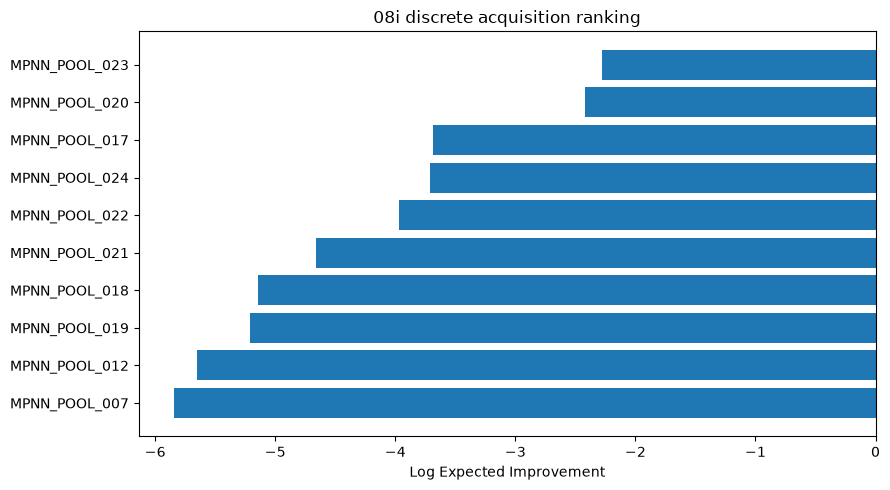

,check,pass
0,full_pool_24,True
1,validated_camsol_complete,True
2,five_real_structural_observations,True
3,nineteen_unobserved_pool_candidates,True
4,botorch_gp_fitted,True
5,proposal_is_existing_unobserved_sequence,True


ALL QC PASSED: True


425

In [7]:
fig,ax=plt.subplots(figsize=(9,5))
top=unobserved.head(10).sort_values("log_expected_improvement")
ax.barh(top.candidate_id,top.log_expected_improvement)
ax.set_xlabel("Log Expected Improvement"); ax.set_title("08i discrete acquisition ranking")
fig.tight_layout(); fig.savefig(FIGURE_DIR/"08i_discrete_logEI_top10.png",dpi=220); plt.show()

qc=pd.DataFrame([
 {"check":"full_pool_24","pass":len(pool)==24},
 {"check":"validated_camsol_complete","pass":bool(pool.camsol_result_validated.all())},
 {"check":"five_real_structural_observations","pass":len(observed)==5},
 {"check":"nineteen_unobserved_pool_candidates","pass":len(unobserved)==19},
 {"check":"botorch_gp_fitted","pass":True},
 {"check":"proposal_is_existing_unobserved_sequence","pass":proposal.candidate_id.iloc[0] in set(unobserved.candidate_id)},
])
qc.to_csv(TABLE_DIR/"08i_QC.csv",index=False); display(qc); print("ALL QC PASSED:",bool(qc["pass"].all()))
prov={"botorch_version":botorch.__version__,"torch_version":torch.__version__,"gpytorch_version":gpytorch.__version__,"seed":20260830,"features":FEATURES,"training_n":len(observed),"pool_n":len(pool),"acquisition":"LogExpectedImprovement evaluated exhaustively on discrete unobserved pool","interpretation":"pilot next-evaluation selector; not affinity prediction"}
(PROVENANCE_DIR/"08i_provenance.json").write_text(json.dumps(prov,indent=2)+"\n")